### pipeline is a function in machine leanring a pipeline is a structured workflow that automates the entire process of turning raw data into predictions—covering data preparation, model training, validation, and deployment.

### its important  to know when to use column tranformer and when to use pipiline :
### if you want to apply mullriple operations on the single column use pipline then connect it to column tranformer that will

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import  Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

df = pd.read_csv(r"C:\Users\pc\Downloads\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
replace = df.replace({ 'male': 1 , 'female':0 , "S":0 , "C":1 , "Q":2 },inplace = True)
replace

C:\Users\pc\AppData\Local\Temp\ipykernel_6424\207624923.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  replace = df.replace({ 'male': 1 , 'female':0 , "S":0 , "C":1 , "Q":2 },inplace = True)


In [12]:
df['Family'] = df['SibSp'] + df['Parch']

In [13]:
df.drop(columns = ['Name','Ticket','Cabin','SibSp','Parch','PassengerId'],inplace= True)

In [14]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,1,22.0,7.2500,0.0,1
1,1,1,0,38.0,71.2833,1.0,1
2,1,3,0,26.0,7.9250,0.0,0
3,1,1,0,35.0,53.1000,0.0,1
4,0,3,1,35.0,8.0500,0.0,0
...,...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,0.0,0
887,1,1,0,19.0,30.0000,0.0,0
888,0,3,0,NaN,23.4500,0.0,3
889,1,1,1,26.0,30.0000,1.0,0


<Axes: >

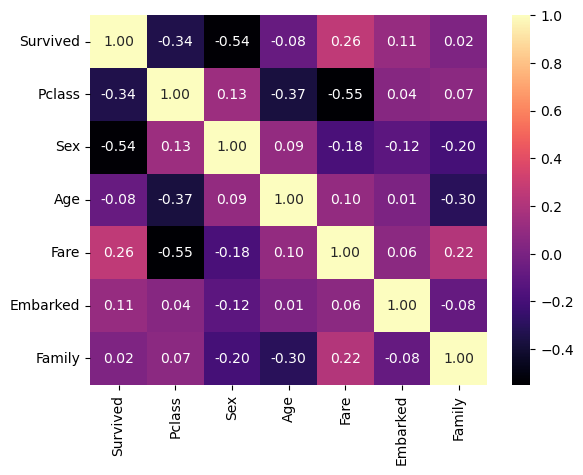

In [15]:
corr = df.corr(numeric_only= True)
sns.heatmap(corr,cmap='magma',annot= True,fmt = '.2f')

In [16]:
# first tranformer for imputing
tf1 = ColumnTransformer([('impute',SimpleImputer(strategy= 'mean'),['Age','Fare'])],remainder= 'passthrough')

In [17]:
X = df.iloc[:,1:6]
y = df.iloc[:,0]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [18]:
pipeline = Pipeline([('impute',tf1),
                    ('model', DecisionTreeClassifier(max_depth= 5 , random_state= 42))])

In [19]:
# to display the whole pipline
from sklearn import set_config
set_config(display='diagram')

In [20]:
pipeline.fit(X_train,y_train)

e:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('impute',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute', SimpleImputer(),
                                                  ['Age', 'Fare'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [21]:
pred = pipeline.predict(X_test)

In [22]:
pipeline.named_steps['impute'].transformers_[0][1].statistics_

array([30.00562284, 32.14281854])

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.7932960893854749